In [42]:
import pandas as pd
import numpy as np
import geopandas as gpd
import folium
import gpx_analysis as gpxa
import fiona
import matplotlib.pyplot as plt
import io
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
paths = ["gpx_data\\arlington_gravel_loop.gpx"]

In [11]:
dfs = []
for path in paths:
    points = gpxa.read_simple_gpx(path, reverse=False)
    df = gpxa.analyze_steps(points, rolling_window=3)
    df['name'] = path.split(".gpx")[0]
    dfs.append(df)
df = pd.concat(dfs, ignore_index=True)

In [61]:
import gpx_analysis.site
from IPython.display import SVG, display

In [67]:
print(gpx_analysis.site.route_elevation_svg(df))

  "http://www.w3.org/Graphics/SVG/1.1/DTD/svg11.dtd">
<svg xmlns:xlink="http://www.w3.org/1999/xlink" width="223.2pt" height="74.844pt" viewBox="0 0 223.2 74.844" xmlns="http://www.w3.org/2000/svg" version="1.1">
 <metadata>
  <rdf:RDF xmlns:dc="http://purl.org/dc/elements/1.1/" xmlns:cc="http://creativecommons.org/ns#" xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#">
   <cc:Work>
    <dc:type rdf:resource="http://purl.org/dc/dcmitype/StillImage"/>
    <dc:date>2026-04-30T09:46:28.410677</dc:date>
    <dc:format>image/svg+xml</dc:format>
    <dc:creator>
     <cc:Agent>
      <dc:title>Matplotlib v3.10.8, https://matplotlib.org/</dc:title>
     </cc:Agent>
    </dc:creator>
   </cc:Work>
  </rdf:RDF>
 </metadata>
 <defs>
  <style type="text/css">*{stroke-linejoin: round; stroke-linecap: butt}</style>
 </defs>
 <g id="figure_1">
  <g id="patch_1">
   <path d="M 0 74.844 
L 223.2 74.844 
L 223.2 0 
L 0 0 
L 0 74.844 
z
" style="fill: none"/>
  </g>
  <g id="axes_1">
   <g id="lin

In [65]:
display(SVG(gpx_analysis.site.route_elevation_svg(df)))

ExpatError: syntax error: line 1, column 2

In [64]:
display(gpx_analysis.site.route_elevation_svg(df))

'  "http://www.w3.org/Graphics/SVG/1.1/DTD/svg11.dtd">\n<svg xmlns:xlink="http://www.w3.org/1999/xlink" width="223.2pt" height="74.844pt" viewBox="0 0 223.2 74.844" xmlns="http://www.w3.org/2000/svg" version="1.1">\n <metadata>\n  <rdf:RDF xmlns:dc="http://purl.org/dc/elements/1.1/" xmlns:cc="http://creativecommons.org/ns#" xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#">\n   <cc:Work>\n    <dc:type rdf:resource="http://purl.org/dc/dcmitype/StillImage"/>\n    <dc:date>2026-04-30T09:45:47.245644</dc:date>\n    <dc:format>image/svg+xml</dc:format>\n    <dc:creator>\n     <cc:Agent>\n      <dc:title>Matplotlib v3.10.8, https://matplotlib.org/</dc:title>\n     </cc:Agent>\n    </dc:creator>\n   </cc:Work>\n  </rdf:RDF>\n </metadata>\n <defs>\n  <style type="text/css">*{stroke-linejoin: round; stroke-linecap: butt}</style>\n </defs>\n <g id="figure_1">\n  <g id="patch_1">\n   <path d="M 0 74.844 \nL 223.2 74.844 \nL 223.2 0 \nL 0 0 \nL 0 74.844 \nz\n" style="fill: none"/>\n  </g>\n 

In [43]:
def basic_elevation_plot(df):
    fig, ax = plt.subplots(figsize=(4, 2))
    df["elevation_f"].rolling(10).mean().plot(ax=ax, linewidth=3)
    ax.plot(
        np.arange(0, len(df)),
        np.ones(len(df)) * df["elevation_f"].min(),
        linewidth=4,
        color="grey",
        linestyle=":",
        alpha=0.6,
    )
    ax.set_axis_off()
    f = io.StringIO()
    fig.savefig(f, format='svg')
    svg_data = f.getvalue()
    return svg_data

'<?xml version="1.0" encoding="utf-8" standalone="no"?>\n<!DOCTYPE svg PUBLIC "-//W3C//DTD SVG 1.1//EN"\n  "http://www.w3.org/Graphics/SVG/1.1/DTD/svg11.dtd">\n<svg xmlns:xlink="http://www.w3.org/1999/xlink" width="288pt" height="144pt" viewBox="0 0 288 144" xmlns="http://www.w3.org/2000/svg" version="1.1">\n <metadata>\n  <rdf:RDF xmlns:dc="http://purl.org/dc/elements/1.1/" xmlns:cc="http://creativecommons.org/ns#" xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#">\n   <cc:Work>\n    <dc:type rdf:resource="http://purl.org/dc/dcmitype/StillImage"/>\n    <dc:date>2026-04-30T09:33:58.073098</dc:date>\n    <dc:format>image/svg+xml</dc:format>\n    <dc:creator>\n     <cc:Agent>\n      <dc:title>Matplotlib v3.10.8, https://matplotlib.org/</dc:title>\n     </cc:Agent>\n    </dc:creator>\n   </cc:Work>\n  </rdf:RDF>\n </metadata>\n <defs>\n  <style type="text/css">*{stroke-linejoin: round; stroke-linecap: butt}</style>\n </defs>\n <g id="figure_1">\n  <g id="patch_1">\n   <path d="M 0 1

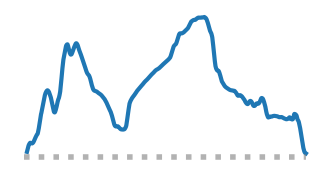

In [44]:
basic_elevation_plot(df)

In [21]:
gpxa.aggregate_by_hazard(df, column='step_dist_f')

,hazard,hazard_label,step_dist_f,percent
0,mellow,Mellow,50507.0,64.0
1,climb,Climb,17057.0,22.0
2,descent,Descent,7182.0,9.0
3,steep_climb,Steep Climb,3053.0,4.0
4,danger_zone,Danger Zone,795.0,1.0
5,TOTAL,TOTAL,78594.0,100.0


In [62]:
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326").to_crs(26910)
gdf_segments = gpxa.points_to_segments(gdf).to_crs(26910)

In [69]:
gdf_segments = gpxa.points_to_segments(gdf)
gdf_segments['BART'] = gpxa.geo.add_bart_station(gdf)
gdf_segments = gpxa.prepare_segment_display_columns(gdf_segments)

In [67]:
ride_cols = ['Ride Type',
        'Turn',
        'Grade',
        'More Details']
m = gpxa.make_route_map(gdf_segments, popup_cols=ride_cols)
m


In [17]:
import numpy as np

def compute_coast_speed(df, v0=0.0,
                        m_lb=190,        # kg (rider + bike)
                        CdA=0.40,      # m^2
                        Crr=0.005,     # -
                        rho=1.225,     # kg/m^3
                        g=9.81):
    """
    Coasting speed compounded across segments.
    Assumes: downhill segments have NEGATIVE grade (e.g., -0.10 for -10%).
    Requires columns:
      - step_grade (decimal)
      - step_dist_m (meters)
    """
    m = m_lb * 0.45359237 # kg
    grade = df["step_grade"].fillna(0).to_numpy(dtype=float)
    L = df["step_dist_m"].fillna(0).to_numpy(dtype=float)

    speeds = np.empty(len(df), dtype=float)
    v = float(v0)

    k_drag = rho * CdA / m  # constant in the v^2 drag term

    for i in range(len(df)):
        # Convert "negative = downhill" into a positive downhill component
        downhill_component = -grade[i]  # e.g. grade=-0.10 => downhill_component=+0.10

        # Update v^2 using a simple energy/force approximation over distance
        v2 = (
            v**2
            + 2.0 * g * (downhill_component - Crr) * L[i]
            - k_drag * v*v * L[i]
        )

        v = np.sqrt(v2) if v2 > 0 else 0.0
        speeds[i] = v

    df = df.copy()
    df["coast_speed_mps"] = speeds
    df["coast_speed_mph"] = speeds * 2.2369362920544
    return df

In [18]:
# compute_coast_speed(gdf_segments).explore(tooltip="coast_speed_mph", column='coast_speed_mph', style_kwds={"weight": 6}, vmin=0, vmax=40)

In [ ]:
gdf_segments_enriched = gpxa.enrich_segments_with_osm_edges(gdf_segments)
gdf_segments_enriched = gpxa.prepare_osm_columns(gdf_segments_enriched)
stops = gpxa.stop_signs_on_segments(gdf_segments)

In [ ]:
lights = stops[stops["highway"] == "traffic_signals"]
stops  = stops[stops["highway"] == "stop"]

In [ ]:
ride_cols = ['Ride Type',
        'Turn',
        'Grade',
        'More Details']
popup_cols = ['Road Name', 'Road Type', 'Speed Limit']
m = gpxa.make_route_map(gdf_segments_enriched, popup_cols=popup_cols + ride_cols)
gdf.iloc[[gdf['elevation_m'].argmax()]].explore(m=m,  marker_type="marker",
    tooltip=['elevation_f'],
    marker_kwds={
        "icon": folium.Icon(
            color="black",icon="mountain", prefix='fa'
        )
    })
stops.explore(
    m=m,
    tooltip=["highway", "street_count", "More Details"],
    marker_kwds={"radius": 4, "color": "red"},
)
lights.explore(
    m=m,
    tooltip=["highway", "street_count", "More Details"],
    marker_kwds={"radius": 4, "color": "blue", "shape": "square"},
)
m
